Load preprocessed data


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from captum.attr import IntegratedGradients, FeatureAblation, Saliency

data = np.load('preprocessed_data.npz')
X_lstm_input = data['X_lstm']
y_flat_bin = data['y_bin']

d:\miniconda\envs\final_xai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Training

In [3]:
#model architecture
class PearsonLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=64, num_layers=2):
        super(PearsonLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3) 
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :]) 
        out = self.fc(out)
        return self.sigmoid(out)

model_jin = PearsonLSTM().cuda()

In [9]:
#train
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
final_results = []
model_jin = PearsonLSTM(input_size=32).cuda()
optimizer = optim.Adam(model_jin.parameters(), lr=0.001)
criterion = nn.BCELoss()
num_subjects = X_lstm_input.shape[0] // 40
groups = np.repeat(np.arange(num_subjects), 40)

for train_idx, test_idx in logo.split(X_lstm_input, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    y_train = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1).cuda()
    X_train_pearson = torch.tensor(X_lstm_input[train_idx], dtype=torch.float32).cuda()
    
    model_jin.train()
    for epoch in range(20): 
        optimizer.zero_grad()
        outputs = model_jin(X_train_pearson)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    model_jin.eval()
    with torch.no_grad():
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        X_test_pearson = torch.tensor(X_lstm_input[test_idx], dtype=torch.float32).cuda()
        
        preds = (model_jin(X_test_pearson) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
        print(f"Subject {subject_id}: Accuracy = {acc*100:.2f}%")
        final_results.append({'Subject': subject_id, 'Accuracy': acc})

avg_acc = np.mean([r['Accuracy'] for r in final_results])
print(f"\nSubject-Independent Mean Accuracy: {avg_acc*100:.2f}%")

Subject 1: Accuracy = 85.00%
Subject 2: Accuracy = 85.00%
Subject 3: Accuracy = 45.00%
Subject 4: Accuracy = 72.50%
Subject 5: Accuracy = 57.50%
Subject 6: Accuracy = 75.00%
Subject 7: Accuracy = 80.00%
Subject 8: Accuracy = 87.50%
Subject 9: Accuracy = 77.50%
Subject 10: Accuracy = 62.50%
Subject 11: Accuracy = 95.00%
Subject 12: Accuracy = 95.00%
Subject 13: Accuracy = 80.00%
Subject 14: Accuracy = 77.50%
Subject 15: Accuracy = 85.00%
Subject 16: Accuracy = 77.50%
Subject 17: Accuracy = 85.00%
Subject 18: Accuracy = 92.50%
Subject 19: Accuracy = 85.00%
Subject 20: Accuracy = 95.00%
Subject 21: Accuracy = 35.00%
Subject 22: Accuracy = 70.00%
Subject 23: Accuracy = 90.00%
Subject 24: Accuracy = 85.00%
Subject 25: Accuracy = 92.50%
Subject 26: Accuracy = 87.50%
Subject 27: Accuracy = 77.50%
Subject 28: Accuracy = 100.00%
Subject 29: Accuracy = 55.00%
Subject 30: Accuracy = 65.00%
Subject 31: Accuracy = 85.00%

Subject-Independent Mean Accuracy: 78.63%


XAI 4

In [11]:
!pip install shap

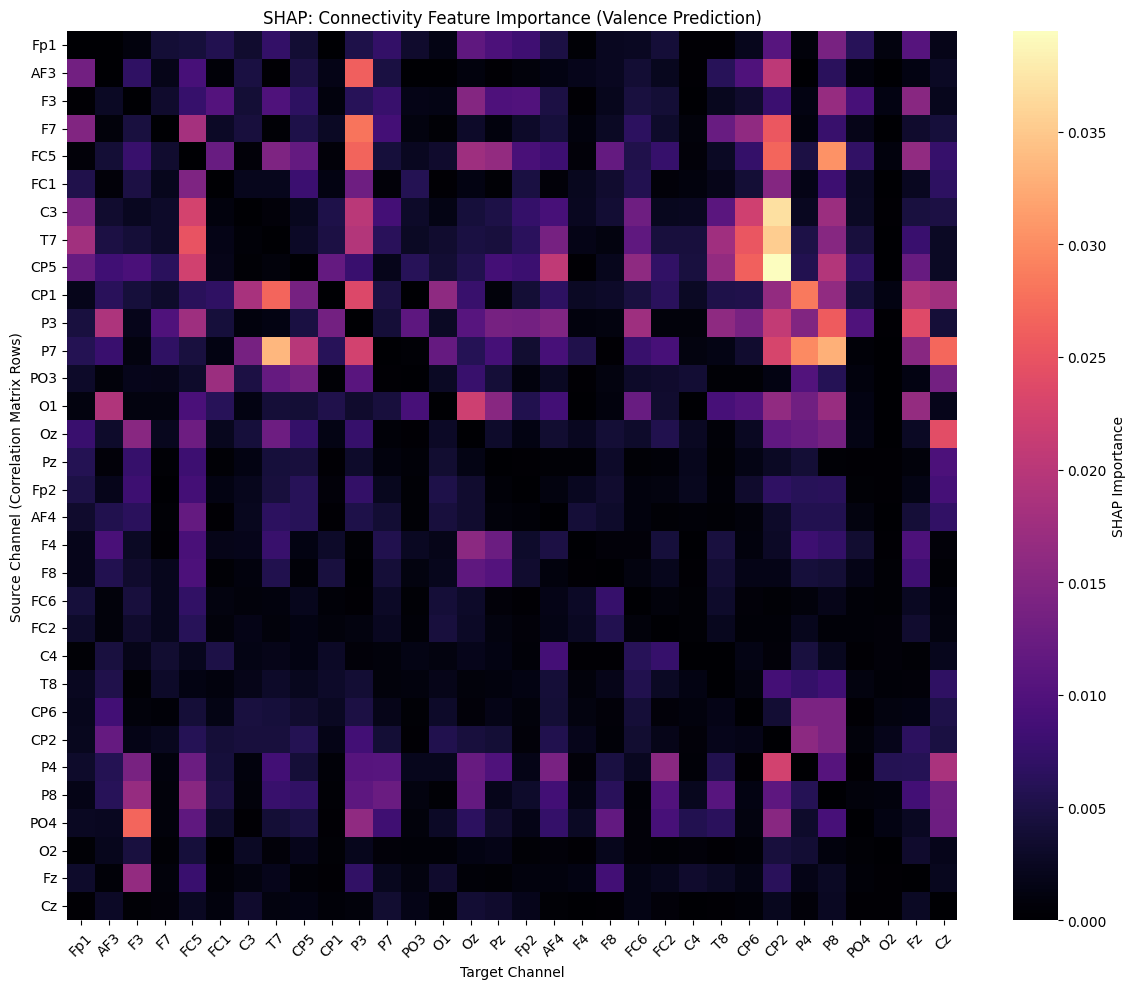

In [ ]:
# SHAP
explainer = shap.DeepExplainer(model_jin, torch.tensor(X_lstm_input[:100], dtype=torch.float32).cuda())
shap_values = explainer.shap_values(torch.tensor(X_lstm_input[:10], dtype=torch.float32).cuda(), check_additivity=False)
mean_shap = np.abs(shap_values).mean(axis=0).squeeze()

deap_channels = ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Fz', 'Cz']
plt.figure(figsize=(12, 10))
sns.heatmap(mean_shap, xticklabels=deap_channels[:32], yticklabels=deap_channels[:32], cmap='magma', cbar_kws={'label': 'SHAP Importance'})
plt.title("SHAP: Connectivity Feature Importance (Valence Prediction)")
plt.xlabel("Target Channel")
plt.ylabel("Source Channel (Correlation Matrix Rows)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import torch

sample_input = torch.tensor(X_lstm_input[:10], dtype=torch.float32).cuda()
sample_input.requires_grad_() 

tensor([[[ 1.0000,  0.8768,  0.7356,  ..., -0.3316, -0.6579, -0.6014],
         [ 0.8768,  1.0000,  0.9043,  ..., -0.4356, -0.7796, -0.6835],
         [ 0.7356,  0.9043,  1.0000,  ..., -0.4721, -0.7831, -0.6715],
         ...,
         [-0.3316, -0.4356, -0.4721,  ...,  1.0000,  0.5749,  0.5842],
         [-0.6579, -0.7796, -0.7831,  ...,  0.5749,  1.0000,  0.8923],
         [-0.6014, -0.6835, -0.6715,  ...,  0.5842,  0.8923,  1.0000]],

        [[ 1.0000,  0.8714,  0.7385,  ..., -0.3276, -0.6617, -0.5924],
         [ 0.8714,  1.0000,  0.9114,  ..., -0.4134, -0.7877, -0.6804],
         [ 0.7385,  0.9114,  1.0000,  ..., -0.4468, -0.7938, -0.6704],
         ...,
         [-0.3276, -0.4134, -0.4468,  ...,  1.0000,  0.5184,  0.5643],
         [-0.6617, -0.7877, -0.7938,  ...,  0.5184,  1.0000,  0.8958],
         [-0.5924, -0.6804, -0.6704,  ...,  0.5643,  0.8958,  1.0000]],

        [[ 1.0000,  0.8807,  0.7605,  ..., -0.3345, -0.6552, -0.5734],
         [ 0.8807,  1.0000,  0.9234,  ..., -0

In [28]:
# Integrated Gradients
torch.backends.cudnn.enabled = False
ig = IntegratedGradients(model_jin)
print("Integrated Gradients done.")

Integrated Gradients done.


In [29]:
#Feature Ablation
ablator = FeatureAblation(model_jin)
ablation_attr = ablator.attribute(sample_input, target=None)
print("Feature Ablation execution done.")

Feature Ablation execution done.


In [ ]:
# Saliency
saliency = Saliency(model_jin)
saliency_attr = saliency.attribute(sample_input, target=None)
print("Saliency execution done.")

Saliency execution done.


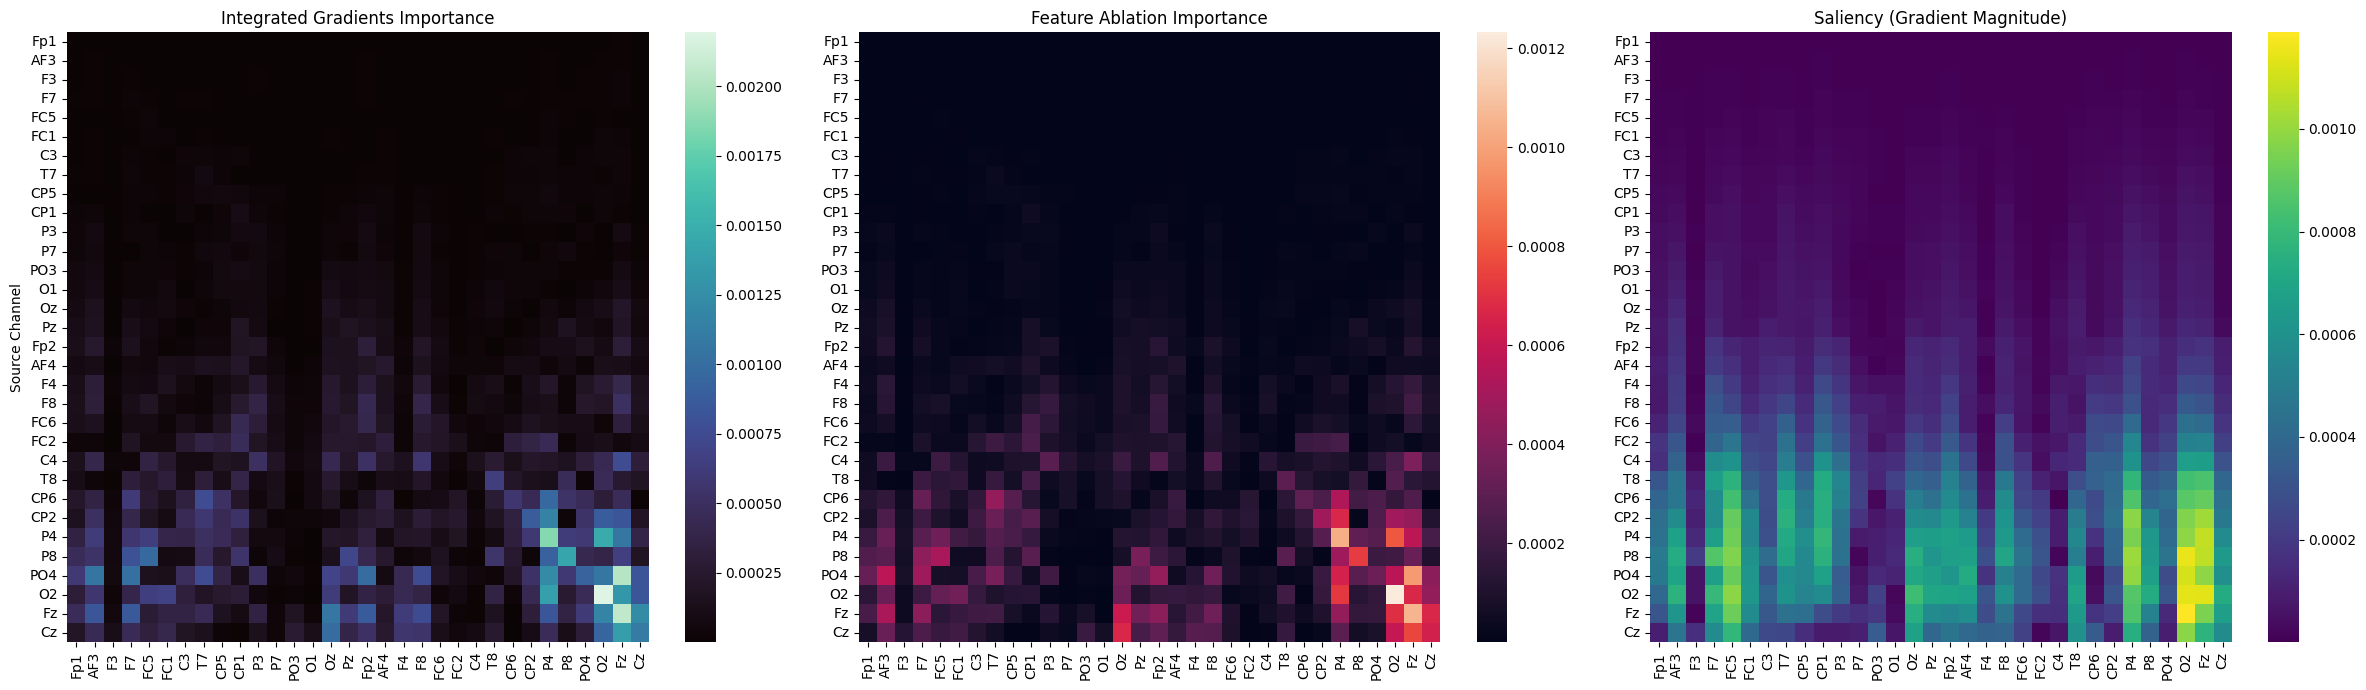

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
def process_attr(attr_tensor):
    return attr_tensor.abs().mean(dim=0).cpu().detach().numpy()

ig_matrix = process_attr(ig_attr)
ablation_matrix = process_attr(ablation_attr)
saliency_matrix = process_attr(saliency_attr)

# Integrated Gradients
sns.heatmap(ig_matrix, ax=axes[0], cmap='mako', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[0].set_title("Integrated Gradients Importance")
axes[0].set_ylabel("Source Channel")

# Feature Ablation
sns.heatmap(ablation_matrix, ax=axes[1], cmap='rocket', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[1].set_title("Feature Ablation Importance")

# Saliency
sns.heatmap(saliency_matrix, ax=axes[2], cmap='viridis', xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[2].set_title("Saliency (Gradient Magnitude)")

plt.tight_layout()
plt.show()

Subject 1: Accuracy = 85.00%


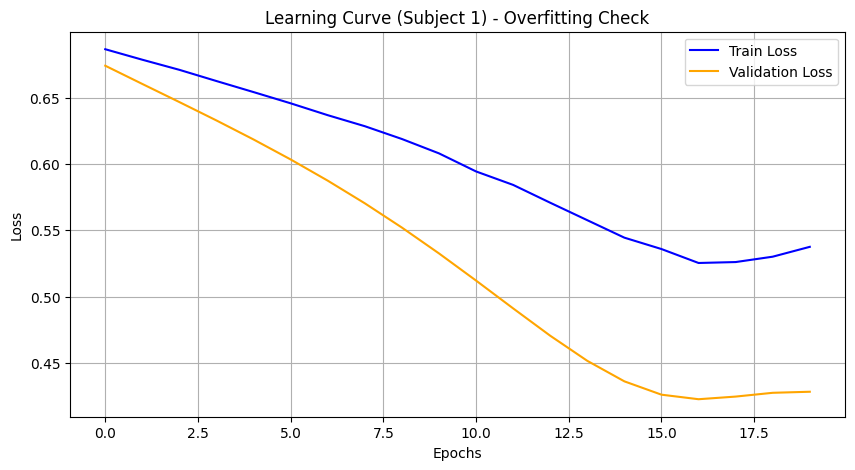


Subject-Independent Mean Accuracy: 85.00%


In [ ]:
import matplotlib.pyplot as plt

logo = LeaveOneGroupOut()
final_results = []
num_subjects = X_lstm_input.shape[0] // 40
groups = np.repeat(np.arange(num_subjects), 40)

for train_idx, test_idx in logo.split(X_lstm_input, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    model_jin = PearsonLSTM(input_size=32).cuda()
    optimizer = optim.Adam(model_jin.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    y_train = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1).cuda()
    X_train_pearson = torch.tensor(X_lstm_input[train_idx], dtype=torch.float32).cuda()
    y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
    X_test_pearson = torch.tensor(X_lstm_input[test_idx], dtype=torch.float32).cuda()

    train_losses = []
    val_losses = []
    
    for epoch in range(20): 
        model_jin.train()
        optimizer.zero_grad()
        outputs = model_jin(X_train_pearson)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        model_jin.eval()
        with torch.no_grad():
            val_outputs = model_jin(X_test_pearson)
            val_loss = criterion(val_outputs, y_test)
            val_losses.append(val_loss.item())
            
    model_jin.eval()
    with torch.no_grad():
        preds = (model_jin(X_test_pearson) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
        print(f"Subject {subject_id}: Accuracy = {acc*100:.2f}%")
        final_results.append({'Subject': subject_id, 'Accuracy': acc})

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', color='blue')  
    plt.plot(val_losses, label='Validation Loss', color='orange')
    plt.title(f"Learning Curve (Subject {subject_id}) - Overfitting Check")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show() 
    
    break 

avg_acc = np.mean([r['Accuracy'] for r in final_results])
print(f"\nSubject-Independent Mean Accuracy: {avg_acc*100:.2f}%")